In [70]:
## this notebook prepares data for training
# - yolo DOTA format using obb bounding box
# - RCNN COCO format using AABB bounding box
# - Mask RCNN additional segmentation attribute


# original dataset
# datasets/all contains all the images
# datasets/mvtect_screws_test.json = original test data annotation
# datasets/mvtect_screws_train.json = original train data annotation
# datasets/mvtect_screws_val.json = original validation data annotation


## Prerequisite

- get the dataset from https://www.mvtec.com/company/research/datasets/mvtec-screws
- create a datasets folder in the same directory with this loadData.ipynb
- extract the zip file and put them under a datasets folder
- you may need to rename the READMEv1.0 file to only README

In [1]:
# from google.colab import drive
# drive.mount("/content/gdrive")

In [15]:
data_root = "datasets"
# data_root = "/content/gdrive/MyDrive/Y3S2/IMG/data"

In [16]:
import json

with open(data_root + "/mvtec_screws_train.json", "r") as f:
    data = json.load(f)

print(data.keys())

# ttl cats
categories = data["categories"]
print(f"Total categories: {len(categories)}")

# ttl imgs
images = data["images"]
print(f"Total images: {len(images)}")

anno = data["annotations"]
print(f"Total annotations: {len(anno)}")

dict_keys(['categories', 'images', 'annotations', 'licenses', 'info'])
Total categories: 13
Total images: 269
Total annotations: 3119


In [17]:
for category in categories:
    print(category)

{'id': 1, 'name': 'type_001', 'supercategory': 'object'}
{'id': 2, 'name': 'type_002', 'supercategory': 'object'}
{'id': 3, 'name': 'type_003', 'supercategory': 'object'}
{'id': 4, 'name': 'type_004', 'supercategory': 'object'}
{'id': 5, 'name': 'type_005', 'supercategory': 'object'}
{'id': 6, 'name': 'type_006', 'supercategory': 'object'}
{'id': 7, 'name': 'type_007', 'supercategory': 'object'}
{'id': 8, 'name': 'type_008', 'supercategory': 'object'}
{'id': 9, 'name': 'type_009', 'supercategory': 'object'}
{'id': 10, 'name': 'type_010', 'supercategory': 'object'}
{'id': 11, 'name': 'type_011', 'supercategory': 'object'}
{'id': 12, 'name': 'type_012', 'supercategory': 'object'}
{'id': 13, 'name': 'type_013', 'supercategory': 'object'}


In [18]:
print(json.dumps(anno[0], indent=4))

{
    "area": 4004.04,
    "bbox": [
        185.4,
        872.465,
        64,
        62.5631,
        0
    ],
    "category_id": 7,
    "id": 1001,
    "image_id": 1,
    "is_crowd": 0
}


In [34]:
with open('datasets/README.md') as f:
  file_contents = f.read()
  print(file_contents)

*******************************************
* MVTec Screws V1.0                       *
*                                         *
* Author: MVTec Software GmbH, July 2020. *
*         https://www.mvtec.com           *
*******************************************

All files are as in the MVTec Screws example dataset for oriented object detection, released with
HALCON version 19.05. The state of the dataset and images is as of release version 20.05.

***********
* License *
***********

The dataset, i.e. the images and the annotations, are licensed under the creative commons
Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0) license. See
https://creativecommons.org/licenses/by-nc-sa/4.0/ for more information.
For using the data in a way that falls under the commercial use clause of the license,
please contact us.

***************
* Attribution *
***************

If you use this dataset in scientific work, please cite our paper:

Markus Ulrich, Patrick Follmann, Jan

In [20]:
from skimage import io

#Load the images, and make some helpful dict to map the data
imgdir = os.path.join(data_root, 'all')

#remap images to dict by id
imgdict = {l['id']:l for l in data['images']}
#read in all images, can take some time
for i in imgdict.values():
  i['image'] = io.imread(os.path.join(imgdir, i['file_name']))[:, :,: 3]  # drop alpha channel, if it's there

# remap annotations to dict by image_id
from collections import defaultdict
annodict = defaultdict(list)
for annotation in data['annotations']:
  annodict[annotation['image_id']].append(annotation)

# setup list of categories
categories = data['categories']
ncategories = len(categories)
cat_ids = [i['id'] for i in categories]
category_names = {7:'nut', 3:'wood screw', 2:'lag wood screw', 8:'bolt',
                  6:'black oxide screw', 5:'shiny screw', 4:'short wood screw',
                  1:'long lag screw', 9:'large nut', 11:'nut', 10:'nut',
                  12:'machine screw', 13:'short machine screw' }

In [60]:
# helper functions to extract the images

from scipy import ndimage
import numpy as np
from typing import List, Tuple
from shapely.geometry import Polygon, box
import json
import os

def unpack_bbox(bbox: List[float]) -> Tuple[np.ndarray, float, float, float]:
    """
    Unpack bounding box parameters from COCO format.

    Args:
        bbox: List of [row, col, width, height, phi] where:
            - row, col: Center coordinates
            - width: Length parallel to orientation
            - height: Length perpendicular to orientation
            - phi: Orientation in radians (mathematically positive)

    Returns:
        Tuple of (rotation_center, width, height, theta)
    """
    rot_center = np.array((bbox[1], bbox[0]))  # (col, row)
    width = bbox[3]  # Length parallel to orientation
    height = bbox[2]  # Length perpendicular to orientation
    theta = -bbox[4] + np.pi/2  # Convert to standard rotation
    return rot_center, width, height, theta

def rotcorners_from_coords(rot_center: np.ndarray, width: float, height: float, theta: float) -> np.ndarray:
    """
    Calculate corner points of rotated bounding box.

    Args:
        rot_center: Center point (col, row)
        width: Width of box
        height: Height of box
        theta: Rotation angle in radians

    Returns:
        Array of 4 corner points
    """
    rotation = np.array((
        (np.cos(theta), -np.sin(theta)),
        (np.sin(theta), np.cos(theta))
    ))

    wvec = np.dot(rotation, (width/2, 0))
    hvec = np.dot(rotation, (0, height/2))
    corner_points = rot_center + np.array([wvec+hvec, wvec-hvec, -wvec+hvec, -wvec-hvec])
    return corner_points

def extract_subimg(im: np.ndarray, rot_center: np.ndarray, width: float, height: float, theta: float) -> np.ndarray:
    """
    Extract and rotate a subimage based on bounding box parameters.

    Args:
        im: Input image
        rot_center: Center point (col, row)
        width: Width of box
        height: Height of box
        theta: Rotation angle in radians

    Returns:
        Extracted and rotated subimage
    """
    # Calculate bounding box for extraction
    corner_points = rotcorners_from_coords(rot_center, width, height, theta)
    rot_bbox = np.array((
        corner_points.min(0),
        corner_points.max(0)
    )).astype(np.int64)

    # Constrain to image boundaries
    rot_bbox[rot_bbox < 0] = 0
    rot_bbox[0, 0] = min(rot_bbox[0, 0], im.shape[1])
    rot_bbox[0, 1] = min(rot_bbox[0, 1], im.shape[0])
    rot_bbox[1, 0] = min(rot_bbox[1, 0], im.shape[1])
    rot_bbox[1, 1] = min(rot_bbox[1, 1], im.shape[0])

    # Extract subimage
    subimg = im[rot_bbox[0,1]:rot_bbox[1,1], rot_bbox[0,0]:rot_bbox[1,0]]

    # Rotate subimage
    rotated_im = ndimage.rotate(subimg, np.degrees(theta)+180)

    # Center and crop to exact dimensions
    newcenter = (np.array(rotated_im.shape)/2).astype(np.int64)
    rotated_im = rotated_im[
        int(newcenter[0]-height/2):int(newcenter[0]+height/2),
        int(newcenter[1]-width/2):int(newcenter[1]+width/2),
        :3  # Drop alpha channel if present
    ]

    return rotated_im

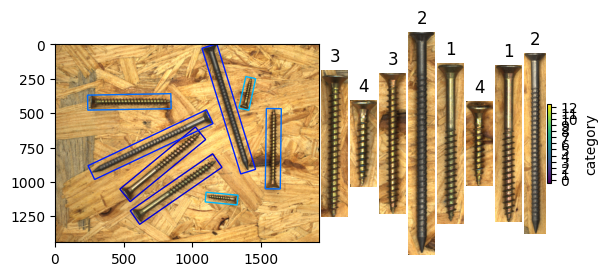

In [32]:
from scipy import ndimage
from matplotlib import pyplot as plt
from matplotlib import rcParams, gridspec
from matplotlib import patches, transforms as plt_transforms
import numpy as np

def viewImgNAnno(imageid):
  im = imgdict[imageid]['image']
  gs = gridspec.GridSpec(1, 1 + len(annodict[imageid]),
                        width_ratios=[1,]+[.1]*len(annodict[imageid]),
                        wspace=.05)
  plt.figure()
  ax = plt.subplot(gs[0])
  plt.imshow(im)
  cmap_normal = plt.Normalize(0, ncategories)

  for i, annotation in enumerate(annodict[imageid]):
    bbox = annotation['bbox']

    # plt.scatter(*rot_center)
    # plt.scatter(*corner_points.T, c='r')

    ax = plt.subplot(gs[0])
    color = plt.cm.jet(cmap_normal(annotation['category_id']))
    rect = patches.Rectangle((bbox[1] - bbox[3]/2 ,
                              bbox[0] - bbox[2]/2), bbox[3], bbox[2],
                            linewidth=1, edgecolor=color, facecolor='none')
    t = plt_transforms.Affine2D().rotate_around(bbox[1], bbox[0], -bbox[4]+np.pi/2)
    rect.set_transform(t + plt.gca().transData)
    ax.add_patch(rect)

    plt.subplot(gs[i + 1])

    rot_center, width, height, theta = unpack_bbox(bbox)
    rotated_im = extract_subimg(im, rot_center, width, height, theta)
    plt.imshow(rotated_im)
    plt.axis('off')
    plt.title(annotation['category_id'])

  plt.colorbar(ticks=range(ncategories), label='category')
  plt.clim(-0.5, ncategories - .5)
  plt.show()


imageid = 100
viewImgNAnno(imageid)

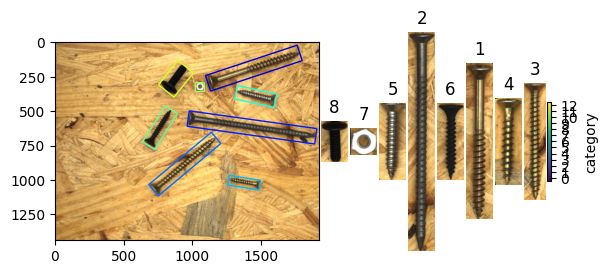

In [33]:
imageid = 50
viewImgNAnno(imageid)

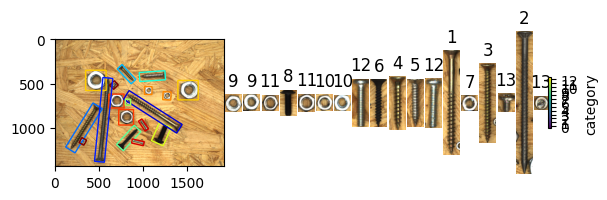

In [35]:
imageid = 70
viewImgNAnno(imageid)

In [36]:
from typing import List
from pycocotools.coco import COCO
from pathlib import Path

def init_COCO(json_path:str, divs:List[str]):

    result = {}
    for target in divs:
        file = Path(f"{json_path}/mvtec_screws_{target}.json")
        db = COCO(file)

        ids = db.getImgIds()
        imgs = db.loadImgs(ids)
        annIds = db.getAnnIds(ids)
        print(f"Found {len(imgs)} {target} images")
        result.update({target: {"coco": db,
                                "ids": ids,
                                "img_data": imgs,
                                "annotations": db.loadAnns(annIds)}
                       })
    return result

In [37]:
data = init_COCO(data_root, ["train", "val", "test"])

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Found 269 train images
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Found 55 val images
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Found 60 test images


In [38]:
data.get("train")['img_data'][0]

{'file_name': 'screws_002.png',
 'height': 1440,
 'width': 1920,
 'id': 1,
 'license': 1}

In [42]:
# move to separate train, test, val folders
import os
import shutil

def sep_imgs(data, images_dir):
  parent_dir = os.path.dirname(images_dir)

  for name, dataset in data.items():
    dataset_dir = os.path.join(parent_dir, "RCNN_YOLO_SET_2", name, "images")
    os.makedirs(dataset_dir, exist_ok=True)

    for img_info in dataset["img_data"]:
        file_name = img_info["file_name"]
        src_path = os.path.join(images_dir, file_name)
        dest_path = os.path.join(dataset_dir, file_name)

        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
            print(f"Copied: {file_name} -> {dataset_dir}")
        else:
            print(f"Warning: {file_name} not found in {images_dir}")

In [43]:
sep_imgs(data, "datasets/all")

Copied: screws_002.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_003.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_004.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_005.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_007.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_008.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_009.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_011.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_012.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_013.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_014.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_016.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_018.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_019.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_020.png -> datasets\RCNN_YOLO_SET_2\train\images
Copied: screws_021.png -> datasets\RCNN_

In [120]:
# Convert to RCNN + YOLO structure
# datasets/
# └── YOLO/
    # ├── RCNN_YOLO_SET/
    # │   ├── annotations/
    # │   ├── images/
    # │   └── labels/
    # └── train/
    # │   ├── annotations/
    # │   ├── images/
    # │   └── labels/
    # └── val/
    # │   ├── annotations/
    # │   ├── images/
    # │   └── labels/
#     └── dataset.yaml


In [44]:
data["train"]["img_data"][0]

{'file_name': 'screws_002.png',
 'height': 1440,
 'width': 1920,
 'id': 1,
 'license': 1}

In [45]:
data["train"]["annotations"][0]


{'area': 4004.04,
 'bbox': [185.4, 872.465, 64, 62.5631, 0],
 'category_id': 7,
 'id': 1001,
 'image_id': 1,
 'is_crowd': 0}

## CREATE YOLO LABELS

-- classID x1, y1, x2, y2, x3, y3, x4, y4

In [49]:
def create_yolo_obb_labels(data, images_dir):
    # Get parent directory
    parent_dir = os.path.dirname(images_dir)

    labels_dir = os.path.join(parent_dir, 'labels')
    os.makedirs(labels_dir, exist_ok=True)
    
    # Create labels directory structure
    for split in ['train', 'val', 'test']:
        
        # Get annotations for this split
        annotations = data[split]['annotations']
        img_data = data[split]['img_data']
        
        # Create a mapping from image_id to filename
        img_id_to_filename = {img['id']: img['file_name'] for img in img_data}
        
        # Group annotations by image_id
        img_annotations = {}
        for ann in annotations:
            img_id = ann['image_id']
            if img_id not in img_annotations:
                img_annotations[img_id] = []
            img_annotations[img_id].append(ann)
        
        # Process each image's annotations
        for img_id, anns in img_annotations.items():
            filename = img_id_to_filename[img_id]
            # Remove extension and add .txt
            label_filename = os.path.splitext(filename)[0] + '.txt'
            label_path = os.path.join(labels_dir, label_filename)
            
            # Get image dimensions
            img_info = next(img for img in img_data if img['id'] == img_id)
            img_w = img_info['width']
            img_h = img_info['height']
            
            with open(label_path, 'w') as f:
                for ann in anns:
                    # Get bbox parameters
                    bbox = ann['bbox']
                    class_id = ann['category_id'] - 1  # Convert to 0-based index
                    
                    # Get the four corners of the rotated rectangle
                    rot_center, width, height, theta = unpack_bbox(bbox)
                    corners = rotcorners_from_coords(rot_center, width, height, theta)
                    
                    # Normalize coordinates (divide by image width and height)
                    corners = corners / [img_w, img_h]
                    
                    # Flatten corners array and convert to string
                    corners_str = ' '.join([f'{c:.6f}' for corner in corners for c in corner])
                    
                    # Write to file in YOLO OBB format: class_id x1 y1 x2 y2 x3 y3 x4 y4
                    f.write(f'{class_id} {corners_str}\n')
            
            print(f"Created label file: {label_path}")


In [50]:
for name, dataset in data.items():
    create_yolo_obb_labels(data, f"datasets\RCNN_YOLO_SET_2\{name}\images")

Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_002.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_003.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_004.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_005.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_007.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_008.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_009.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_011.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_012.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_013.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_014.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_016.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\labels\screws_018.txt
Created label file: datasets\RCNN_YOLO_SET_2\train\

## CREATE RCNN LABELS

-- using the original coco format, but change the obb style to aabb style
-- use polygon bounds to find the minimum rect that consist of the object

In [62]:
def obb_to_aabb(bbox: List[float]) -> List[float]:
    """
    Convert oriented bounding box to axis-aligned bounding box.
    Returns [x_min, y_min, width, height] format
    """
    # Get OBB corners
    rot_center, width, height, theta = unpack_bbox(bbox)
    corners = rotcorners_from_coords(rot_center, width, height, theta)
    
    # Create Shapely polygon from corners
    poly = Polygon(corners)
    
    # Get AABB
    minx, miny, maxx, maxy = poly.bounds
    
    # Return in COCO format [x_min, y_min, width, height]
    return [minx, miny, maxx - minx, maxy - miny]

In [63]:
def convert_dataset_to_aabb(data_root: str, split: str):
    """
    Convert entire dataset from OBB to AABB format.
    """
    # Read COCO format json
    json_path = os.path.join(data_root, f"mvtec_screws_{split}.json")
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Convert each annotation
    for ann in data['annotations']:
        bbox_obb = ann['bbox']
        bbox_aabb = obb_to_aabb(bbox_obb)
        ann['bbox'] = bbox_aabb
        # Remove rotation information if it exists
        if 'rotation' in ann:
            del ann['rotation']
    
    # Save converted annotations
    parent_dir = os.path.join(data_root, "RCNN_YOLO_SET_2", split)

    labels_dir = os.path.join(parent_dir, 'annotations')
    os.makedirs(labels_dir, exist_ok=True)
    output_path = os.path.join(labels_dir, "instances.json")
    with open(output_path, 'w') as f:
        json.dump(data, f, indent=2)
    
    return data

In [56]:
train_data = convert_dataset_to_aabb(data_root, "train")
val_data = convert_dataset_to_aabb(data_root, "val")
test_data = convert_dataset_to_aabb(data_root, "test")

## Prepare Segmentation mask


- add one more attribute in the json, called segmentation, 
- which is actually the original coco coverted to obb like in yolo
- but yolo normalise, this does not

In [64]:
import os

def add_segmentation_masks(data_root: str, divs:List[str]):
    """
    Add segmentation masks to the dataset using the corners of oriented bounding boxes.
    """
    for target in divs:
        json_path = os.path.join(data_root, f"mvtec_screws_{target}.json")
        with open(json_path, 'r') as f:
            data = json.load(f)
            
        
        for ann in data['annotations']:
            bbox = ann['bbox']
            
            
            rot_center, width, height, theta = unpack_bbox(bbox)
            corners = rotcorners_from_coords(rot_center, width, height, theta)
            
            segmentation = corners.flatten().tolist()

            bbox_aabb = obb_to_aabb(bbox)
            ann['bbox'] = bbox_aabb             
            ann['segmentation'] = [segmentation]
        
        output_path = os.path.join(data_root, f"mvtec_screws_{target}_with_seg.json")
        with open(output_path, 'w') as f:
            json.dump(data, f, indent=2)
    
    return data

In [65]:
data = add_segmentation_masks(data_root, ["train", "val", "test"])